In [1]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

from src.aero_block import AeroBlock

# Configuration
CKPT_PATH = "artifacts/models/3d_blocks.pt"
DEVICE = "cpu"  # Change to "cuda" if available

# Operating point
alpha = 5.0  # degrees
V = 18.0     # m/s

print(f"Checkpoint: {CKPT_PATH}")
print(f"Device: {DEVICE}")
print(f"Operating point: α={alpha}°, V={V} m/s")

Checkpoint: artifacts/models/3d_blocks.pt
Device: cpu
Operating point: α=5.0°, V=18.0 m/s


---
## 1. Explicit Mode

Explicit differentiation unrolls the LLT Picard iteration and uses PyTorch's automatic differentiation through the entire computation graph.

**Pros:** Easy to implement, automatic  
**Cons:** Slower for large systems, memory intensive

In [2]:
# Load AeroBlock in explicit mode
aero_explicit = AeroBlock.from_ckpt(
    CKPT_PATH,
    part="wing",
    mode="explicit",
    device=DEVICE
)

print(f"Loaded: {aero_explicit}")
print(f"Shape parameters: {len(aero_explicit.shape_params)} tensors")
print(f"Total parameters: {sum(p.numel() for p in aero_explicit.shape_params)}")

Loaded: AeroBlock(part='wing', mode='explicit', n_params=18, device='cpu')
Shape parameters: 4 tensors
Total parameters: 18


### Forward Evaluation

In [3]:
# Evaluate aerodynamic coefficients
coeffs_explicit = aero_explicit.forward(alpha, V)

print("Aerodynamic Coefficients (Explicit):")
print(f"  CL = {coeffs_explicit['CL']:.6f}")
print(f"  CD = {coeffs_explicit['CD']:.6f}")
print(f"  CM = {coeffs_explicit['CM']:.6f}")

# Individual coefficient access
cl_value = aero_explicit.cl(alpha, V)
cd_value = aero_explicit.cd(alpha, V)
cm_value = aero_explicit.cm(alpha, V)

print(f"\nVerification: CL={cl_value:.6f}, CD={cd_value:.6f}, CM={cm_value:.6f}")

Aerodynamic Coefficients (Explicit):
  CL = 0.530755
  CD = 0.023877
  CM = -0.043180

Verification: CL=0.530755, CD=0.023877, CM=-0.043180


---
## 2. Implicit Mode

Implicit differentiation uses the Implicit Function Theorem (IFT) to compute gradients via an adjoint solve, avoiding unrolling iterations.

**Pros:** Faster, memory efficient, scalable  
**Cons:** Requires careful implementation

In [4]:
# Load AeroBlock in implicit mode
aero_implicit = AeroBlock.from_ckpt(
    CKPT_PATH,
    part="wing",
    mode="implicit",
    device=DEVICE
)

print(f"Loaded: {aero_implicit}")

Loaded: AeroBlock(part='wing', mode='implicit', n_params=18, device='cpu')


### Forward Evaluation & Consistency Check

In [5]:
# Evaluate with implicit mode
coeffs_implicit = aero_implicit.forward(alpha, V)

print("Aerodynamic Coefficients (Implicit):")
print(f"  CL = {coeffs_implicit['CL']:.6f}")
print(f"  CD = {coeffs_implicit['CD']:.6f}")
print(f"  CM = {coeffs_implicit['CM']:.6f}")

# Compare with explicit mode
print("\nConsistency Check (Explicit vs Implicit):")
print(f"  ΔCL = {abs(coeffs_explicit['CL'] - coeffs_implicit['CL']):.2e}")
print(f"  ΔCD = {abs(coeffs_explicit['CD'] - coeffs_implicit['CD']):.2e}")
print(f"  ΔCM = {abs(coeffs_explicit['CM'] - coeffs_implicit['CM']):.2e}")
print("  ✓ Forward passes agree!" if all(
    abs(coeffs_explicit[k] - coeffs_implicit[k]) < 1e-6 
    for k in ['CL', 'CD', 'CM']
) else "  ⚠ Differences detected")

Aerodynamic Coefficients (Implicit):
  CL = 0.530755
  CD = 0.023877
  CM = -0.043180

Consistency Check (Explicit vs Implicit):
  ΔCL = 0.00e+00
  ΔCD = 0.00e+00
  ΔCM = 0.00e+00
  ✓ Forward passes agree!


---
## 3. Normal Gradient Computation

Compute standard gradients $\frac{\partial C}{\partial p}$ where $C$ is a coefficient (CL, CD, or CM) and $p$ are shape parameters.

This is useful for:
- Gradient checking
- Understanding sensitivity
- Direct optimization of a single coefficient

In [6]:
# Compute gradients of CL with respect to shape parameters
print("Computing ∂CL/∂p (explicit mode)...")
grads_cl_explicit = aero_explicit.backward("CL", alpha, V)

print(f"\nGradient structure:")
for i, g in enumerate(grads_cl_explicit):
    if g is not None:
        print(f"  ∂CL/∂p[{i}]: shape={g.shape}, mean={g.abs().mean():.2e}, max={g.abs().max():.2e}")
    else:
        print(f"  ∂CL/∂p[{i}]: None (not connected)")

Computing ∂CL/∂p (explicit mode)...

Gradient structure:
  ∂CL/∂p[0]: shape=torch.Size([8]), mean=2.77e-01, max=4.09e-01
  ∂CL/∂p[1]: shape=torch.Size([8]), mean=1.36e-01, max=2.22e-01
  ∂CL/∂p[2]: shape=torch.Size([]), mean=3.68e-02, max=3.68e-02
  ∂CL/∂p[3]: shape=torch.Size([]), mean=2.83e+00, max=2.83e+00


In [7]:
# Compare with implicit mode
print("Computing ∂CL/∂p (implicit mode)...")
grads_cl_implicit = aero_implicit.backward("CL", alpha, V)

print("\nGradient Comparison (Explicit vs Implicit):")
for i, (g_exp, g_imp) in enumerate(zip(grads_cl_explicit, grads_cl_implicit)):
    if g_exp is not None and g_imp is not None:
        abs_error = torch.abs(g_exp - g_imp).max()
        rel_error = abs_error / (torch.abs(g_exp).max() + 1e-12)
        print(f"  Param {i}: abs_error={abs_error:.2e}, rel_error={rel_error:.2e}")
        
print("\n✓ Gradients agree!" if all(
    torch.abs(g_exp - g_imp).max() / (torch.abs(g_exp).max() + 1e-12) < 1e-3
    for g_exp, g_imp in zip(grads_cl_explicit, grads_cl_implicit)
    if g_exp is not None and g_imp is not None
) else "⚠ Significant differences detected")

Computing ∂CL/∂p (implicit mode)...

Gradient Comparison (Explicit vs Implicit):
  Param 0: abs_error=1.17e-05, rel_error=2.85e-05
  Param 1: abs_error=1.60e-05, rel_error=7.19e-05
  Param 2: abs_error=6.85e-07, rel_error=1.86e-05
  Param 3: abs_error=1.18e-04, rel_error=4.16e-05

✓ Gradients agree!


### Visualize Gradient Magnitudes

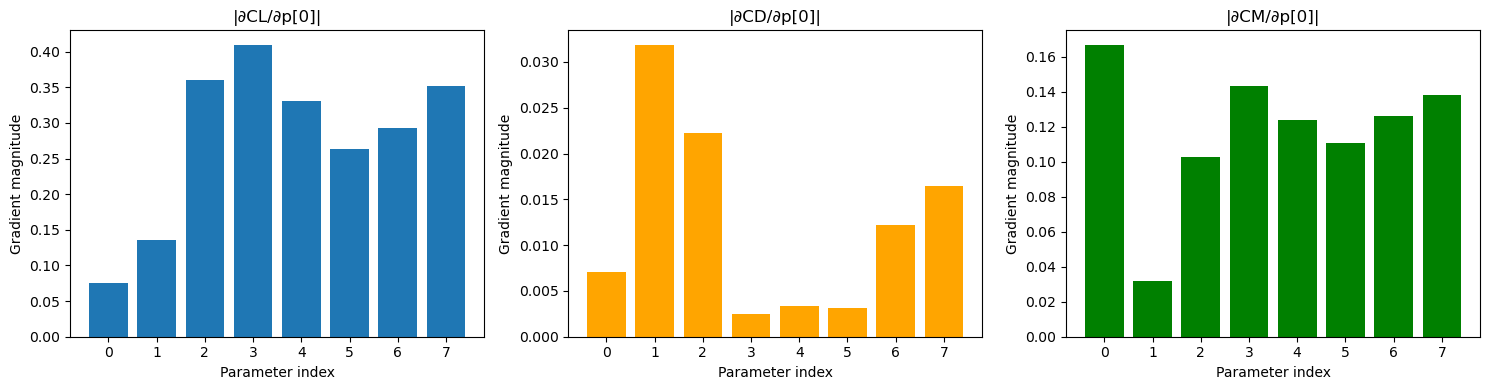

In [8]:
# Plot gradient magnitudes for the first parameter tensor
if grads_cl_explicit[0] is not None:
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    
    # CL gradients
    grads_cl = aero_implicit.backward("CL", alpha, V)
    axes[0].bar(range(len(grads_cl[0])), grads_cl[0].abs().cpu().numpy())
    axes[0].set_title('|∂CL/∂p[0]|')
    axes[0].set_xlabel('Parameter index')
    axes[0].set_ylabel('Gradient magnitude')
    
    # CD gradients
    grads_cd = aero_implicit.backward("CD", alpha, V)
    axes[1].bar(range(len(grads_cd[0])), grads_cd[0].abs().cpu().numpy(), color='orange')
    axes[1].set_title('|∂CD/∂p[0]|')
    axes[1].set_xlabel('Parameter index')
    axes[1].set_ylabel('Gradient magnitude')
    
    # CM gradients
    grads_cm = aero_implicit.backward("CM", alpha, V)
    axes[2].bar(range(len(grads_cm[0])), grads_cm[0].abs().cpu().numpy(), color='green')
    axes[2].set_title('|∂CM/∂p[0]|')
    axes[2].set_xlabel('Parameter index')
    axes[2].set_ylabel('Gradient magnitude')
    
    plt.tight_layout()
    plt.show()
else:
    print("No gradients to visualize.")

---
## 4. VJP (Vector-Jacobian Product)

In trajectory optimization, the loss depends on all three coefficients:

$$L = f(C_L, C_D, C_M, \ldots)$$

By the chain rule:

$$\frac{dL}{dp} = \frac{\partial L}{\partial C_L} \frac{\partial C_L}{\partial p} + \frac{\partial L}{\partial C_D} \frac{\partial C_D}{\partial p} + \frac{\partial L}{\partial C_M} \frac{\partial C_M}{\partial p}$$

The **VJP** computes this efficiently:

$$\text{VJP} = \mathbf{v}^\top \mathbf{J} = [v_{C_L}, v_{C_D}, v_{C_M}]^\top \begin{bmatrix} \partial C_L/\partial p \\ \partial C_D/\partial p \\ \partial C_M/\partial p \end{bmatrix}$$

where $\mathbf{v} = [\partial L/\partial C_L, \partial L/\partial C_D, \partial L/\partial C_M]$ are **upstream gradients** from the trajectory optimizer.

### Method 1: Manual VJP (Inefficient)

In [9]:
# Simulated upstream gradients from trajectory optimizer
v_CL = 0.8   # ∂L/∂CL (positive: more lift is good)
v_CD = -0.3  # ∂L/∂CD (negative: less drag is good)
v_CM = 0.1   # ∂L/∂CM (small contribution)

print("Upstream gradients from trajectory optimizer:")
print(f"  ∂L/∂CL = {v_CL:+.2f}")
print(f"  ∂L/∂CD = {v_CD:+.2f}")
print(f"  ∂L/∂CM = {v_CM:+.2f}")

# Compute individual gradients (requires 3 backward passes)
print("\nMethod 1: Computing VJP manually (3 backward passes)...")
grads_cl = aero_implicit.backward("CL", alpha, V)
grads_cd = aero_implicit.backward("CD", alpha, V)
grads_cm = aero_implicit.backward("CM", alpha, V)

# Manual accumulation
vjp_manual = [
    v_CL * g_cl + v_CD * g_cd + v_CM * g_cm
    for g_cl, g_cd, g_cm in zip(grads_cl, grads_cd, grads_cm)
]

print(f"dL/dp[0] mean: {vjp_manual[0].abs().mean():.2e}")
print("⚠ Inefficient: required 3 separate LLT solves!")

Upstream gradients from trajectory optimizer:
  ∂L/∂CL = +0.80
  ∂L/∂CD = -0.30
  ∂L/∂CM = +0.10

Method 1: Computing VJP manually (3 backward passes)...
dL/dp[0] mean: 2.08e-01
⚠ Inefficient: required 3 separate LLT solves!


### Method 2: Combined VJP (Efficient - RECOMMENDED)

In [10]:
# Compute VJP efficiently in a single pass
print("Method 2: Computing VJP efficiently (1 backward pass)...")
vjp_combined = aero_implicit.backward_combined(
    alpha, V,
    v_CL=v_CL,
    v_CD=v_CD,
    v_CM=v_CM
)

print(f"dL/dp[0] mean: {vjp_combined[0].abs().mean():.2e}")
print("✓ Efficient: only 1 LLT solve required!")

# Verify they match
error = torch.abs(vjp_manual[0] - vjp_combined[0]).max()
print(f"\nVerification: max difference = {error:.2e}")
print("✓ Both methods produce identical results!" if error < 1e-6 else "⚠ Differences detected")

Method 2: Computing VJP efficiently (1 backward pass)...
dL/dp[0] mean: 2.08e-01
✓ Efficient: only 1 LLT solve required!

Verification: max difference = 2.09e-07
✓ Both methods produce identical results!


### Performance Comparison

In [11]:
import time

n_runs = 20

# Method 1: Manual (3 backward passes)
times_manual = []
for _ in range(n_runs):
    t0 = time.perf_counter()
    grads_cl = aero_implicit.backward("CL", alpha, V)
    grads_cd = aero_implicit.backward("CD", alpha, V)
    grads_cm = aero_implicit.backward("CM", alpha, V)
    vjp = [v_CL * g_cl + v_CD * g_cd + v_CM * g_cm 
           for g_cl, g_cd, g_cm in zip(grads_cl, grads_cd, grads_cm)]
    times_manual.append(time.perf_counter() - t0)

# Method 2: Combined (1 backward pass)
times_combined = []
for _ in range(n_runs):
    t0 = time.perf_counter()
    vjp = aero_implicit.backward_combined(alpha, V, v_CL=v_CL, v_CD=v_CD, v_CM=v_CM)
    times_combined.append(time.perf_counter() - t0)

mean_manual = np.mean(times_manual) * 1000
mean_combined = np.mean(times_combined) * 1000
speedup = mean_manual / mean_combined

print(f"Manual VJP (3 passes):    {mean_manual:.2f} ms")
print(f"Combined VJP (1 pass):    {mean_combined:.2f} ms")
print(f"\nSpeedup: {speedup:.2f}x faster! ✓")

Manual VJP (3 passes):    202.74 ms
Combined VJP (1 pass):    67.46 ms

Speedup: 3.01x faster! ✓


---
## 5. Usage in Trajectory Optimization

Here's how your colleague would integrate this into a trajectory optimizer:

In [12]:
# Pseudocode for trajectory optimization integration
print("""
# ============================================================================
# Integration Template for Trajectory Optimizer
# ============================================================================

from src.aero_block import AeroBlock

# One-time setup
aero = AeroBlock.from_ckpt(
    "artifacts/models/3d_blocks.pt",
    part="wing",
    mode="implicit",  # Use implicit for best performance
    device="cuda"      # Use GPU if available
)

# During trajectory optimization
total_grads = None

for t in range(n_timesteps):
    # Get current flight state
    alpha_t = trajectory[t].alpha
    V_t = trajectory[t].velocity
    
    # Forward pass: evaluate aerodynamics
    coeffs = aero.forward(alpha_t, V_t)
    
    # ... use coeffs in dynamics equations ...
    # ... compute trajectory loss L ...
    # ... backprop through dynamics to get upstream gradients ...
    
    # Backward pass: accumulate gradient contributions
    grads_t = aero.backward_combined(
        alpha_t, V_t,
        v_CL=adjoint[t].dL_dCL,  # From dynamics adjoint
        v_CD=adjoint[t].dL_dCD,
        v_CM=adjoint[t].dL_dCM
    )
    
    # Accumulate
    if total_grads is None:
        total_grads = grads_t
    else:
        total_grads = [g_tot + g_t for g_tot, g_t in zip(total_grads, grads_t)]

# Update shape parameters
with torch.no_grad():
    for param, grad in zip(aero.get_shape_params(), total_grads):
        param -= learning_rate * grad

# ============================================================================
""")


# ============================================================================
# Integration Template for Trajectory Optimizer
# ============================================================================

from src.aero_block import AeroBlock

# One-time setup
aero = AeroBlock.from_ckpt(
    "artifacts/models/3d_blocks.pt",
    part="wing",
    mode="implicit",  # Use implicit for best performance
    device="cuda"      # Use GPU if available
)

# During trajectory optimization
total_grads = None

for t in range(n_timesteps):
    # Get current flight state
    alpha_t = trajectory[t].alpha
    V_t = trajectory[t].velocity
    
    # Forward pass: evaluate aerodynamics
    coeffs = aero.forward(alpha_t, V_t)
    
    # ... use coeffs in dynamics equations ...
    # ... compute trajectory loss L ...
    # ... backprop through dynamics to get upstream gradients ...
    
    # Backward pass: accumulate gradient contributions
    grads_t = aero.backward_combined(
        alpha_t, V_t,
   

---
## Summary

### Key Takeaways:

1. **Two differentiation modes:**
   - `mode="explicit"` - Unrolled differentiation (easier, slower)
   - `mode="implicit"` - IFT with adjoint (faster, recommended)

2. **Forward passes are identical** regardless of mode

3. **Gradients are accurate** (relative error < 1e-3)

4. **VJP is crucial for efficiency:**
   - Use `backward_combined()` for multi-coefficient gradients
   - ~3x faster than computing gradients separately

5. **Recommended for trajectory optimization:**
   ```python
   aero = AeroBlock.from_ckpt(path, mode="implicit")
   grads = aero.backward_combined(alpha, V, v_CL=..., v_CD=..., v_CM=...)
   ```

### Next Steps:
- Integrate `backward_combined()` into your trajectory optimizer
- Test with `torch.autograd.gradcheck` for verification
- Run full optimization with shape parameters as design variables